# Evaluation on the test set

This document evaluates one trained machine learning model,
see details below.
We use both conventional metrics and comparison with a 
resimulated image.
There is one methodological flaw in the model training.
The early stopping criterion is based on testing on the same
test set as we use here.

## Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import IPython.display as idp
import toml
import json
import CosmoSim.Image as csimg
import CosmoSim as cs
import CosmoSim.datagen as dg
import CosmoSim.roulettegen as rg
imshow = csimg.imshow

Let us check the parameters underlying this test.
This gives the neural network and hyperparameters used.

In [2]:
cfg = toml.load( "ml.toml" )
print( "CosmoSim version is", cs.__version__ )
print( "Data from directory", cfg["output"]["directory"] )
print( "Nerual network used:", cfg["settings"]["model"] )
print( json.dumps( cfg["hyperparameters"], indent=4 ) )

CosmoSim version is 3.0.2
Data from directory experiment001
Nerual network used: regnet_y_32gf
{
    "learning-rate": 0.0005,
    "batch-size": 64,
    "weight-decay": 4e-05
}


Let's load the test set, both the ground truth (`gt`) and the predictions (`df`).

In [3]:
gt = pd.read_csv( "testing.csv", index_col="filename" )
df = pd.read_csv( "test.csv", index_col="filename" )
display( gt.head() )
display( df.head() )

,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-012001.png,1.822541,-0.583211,0.871805,-95.235235,-26.319681,-0.198978,0.155946,0.122156,0.001594,-0.000480,...,-0.000016,0.000002,0.000009,0.000013,-1.652437e-08,2.780859e-07,3.752260e-07,-4.198803e-08,-1.178024e-07,-2.516951e-07
image-012002.png,1.326376,-136.483724,-29.051266,100.027777,19.397026,-0.342644,0.319490,0.097178,-0.003782,-0.002361,...,-0.000003,-0.000024,0.000051,0.000032,-2.519161e-06,-4.528560e-07,8.703214e-07,2.744315e-07,1.257897e-06,3.455235e-07
image-012003.png,4.979775,2.772299,-1.477676,-3.708814,93.632947,-0.263636,-0.239650,0.107189,0.001760,-0.002374,...,0.000007,0.000030,0.000024,-0.000003,5.060789e-07,-7.420734e-07,-4.856449e-07,-2.009244e-07,-1.266576e-08,3.513574e-07
image-012004.png,1.464460,-59.265898,-37.529097,51.722463,34.242431,-0.263207,0.047208,0.238085,-0.003688,-0.002780,...,-0.000011,-0.000079,-0.000101,0.000010,-2.330983e-06,-2.035995e-06,1.579095e-06,-1.541651e-06,-2.448018e-06,-3.085644e-06
image-012005.png,4.598397,0.227470,1.657518,-19.077319,-14.602243,-0.188412,0.052628,0.179085,0.003500,0.002954,...,-0.000031,-0.000157,-0.000153,0.000098,2.276875e-06,1.355004e-06,-4.001461e-06,7.373580e-06,1.025871e-05,6.803874e-07


,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-012001.png,1.822540,-0.583210,0.871805,-95.235245,-26.319681,-0.198978,0.155946,0.122156,0.001594,-0.000480,...,-0.000016,0.000002,0.000009,0.000013,-1.652438e-08,2.780859e-07,3.752260e-07,-4.198796e-08,-1.178024e-07,-2.516950e-07
image-012002.png,1.326376,-136.483730,-29.051264,100.027780,19.397028,-0.342644,0.319490,0.097178,-0.003782,-0.002361,...,-0.000003,-0.000024,0.000051,0.000032,-2.519161e-06,-4.528560e-07,8.703215e-07,2.744315e-07,1.257897e-06,3.455235e-07
image-012003.png,4.979775,2.772299,-1.477676,-3.708814,93.632940,-0.263636,-0.239650,0.107189,0.001760,-0.002374,...,0.000007,0.000030,0.000024,-0.000003,5.060789e-07,-7.420734e-07,-4.856447e-07,-2.009244e-07,-1.266574e-08,3.513574e-07
image-012004.png,1.464460,-59.265900,-37.529100,51.722460,34.242430,-0.263207,0.047208,0.238085,-0.003688,-0.002780,...,-0.000011,-0.000079,-0.000101,0.000010,-2.330983e-06,-2.035995e-06,1.579095e-06,-1.541651e-06,-2.448018e-06,-3.085644e-06
image-012005.png,4.598397,0.227470,1.657518,-19.077318,-14.602243,-0.188412,0.052628,0.179085,0.003500,0.002954,...,-0.000031,-0.000157,-0.000153,0.000098,2.276875e-06,1.355004e-06,-4.001461e-06,7.373580e-06,1.025871e-05,6.803874e-07


As we can see, we have columns for all the parameters in question, and rows for the individual objects.  There is no superfluous data in the data frames.

We can also check the difference.

In [4]:
rawerrors = gt - df
display( rawerrors.head() )

,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-012001.png,1.856244e-07,-3.002758e-08,7.424289e-08,9.708348e-06,-4.283747e-07,2.012002e-08,-1.960780e-09,7.960554e-09,-2.891040e-11,1.895180e-11,...,1.042780e-12,1.178786e-13,-1.666182e-13,6.621121e-13,1.153089e-14,1.658704e-15,-5.887152e-14,-7.250711e-14,5.623112e-14,-1.963034e-14
image-012002.png,2.508286e-08,5.830589e-06,-1.768028e-06,-2.584227e-06,-1.640674e-06,6.806433e-09,1.700938e-09,8.483530e-09,1.434627e-10,5.121110e-11,...,-1.950431e-13,3.014337e-13,-7.776709e-13,-1.105876e-12,1.496941e-13,-2.755752e-14,-8.882258e-14,2.979810e-14,3.397369e-14,3.503335e-14
image-012003.png,-8.062228e-08,6.349043e-08,-8.063964e-08,1.158263e-07,6.957117e-06,9.682100e-09,9.231984e-09,1.053823e-08,-1.102283e-10,5.397590e-11,...,1.459599e-13,-6.286945e-13,-2.719971e-12,-2.442346e-13,-1.292690e-14,2.592133e-14,-2.101931e-13,4.739536e-14,-2.756708e-14,-1.675887e-14
image-012004.png,7.476854e-08,2.225588e-06,2.595615e-06,3.233856e-06,5.126955e-07,8.357050e-09,-1.281511e-09,1.708021e-08,1.343645e-10,-4.178060e-11,...,-2.204547e-13,2.748926e-12,-2.633600e-12,4.509302e-13,9.415846e-15,-1.625841e-14,1.582424e-14,-8.048477e-15,-1.408045e-13,-2.029713e-13
image-012005.png,6.658437e-08,1.000064e-08,1.109882e-09,-1.289487e-06,-4.291130e-07,1.135861e-08,-4.409466e-09,5.010680e-09,-2.417454e-10,-8.239550e-11,...,2.487108e-13,-5.865800e-12,6.351600e-12,-1.363687e-12,2.261434e-14,-8.216007e-14,3.606736e-13,5.623702e-14,-9.755293e-14,4.519432e-14


That was straight forward.  Now we come to the tricky part - making sense of the numbers.
There are two questions that we want to consider.
1. How well does the model perform overall?
2. How do particular images behave, and what are the best and the worst samples?

## Model evaluation

It is interesting to see how the model behaves on each column.
To see this, we can aggregate the rows, computing the mean of absolute errors and mean of squared errors.

In [5]:
mse = (rawerrors**2).mean()
mae = rawerrors.abs().mean()
mse.name = "MSE"
mae.name = "MAE"
colerrors = pd.concat( [ mse, mae ], axis=1 )
display( colerrors )

,MSE,MAE
sigma,1.629674e-14,1.023236e-07
xiX,4.081217e-12,8.628365e-07
xiY,3.928942e-12,8.644636e-07
alpha[0][1],1.029629e-11,2.090639e-06
beta[0][1],7.151153e-12,1.796591e-06
alpha[1][0],2.251415e-16,1.299155e-08
alpha[1][2],9.360923e-17,6.694653e-09
beta[1][2],1.159449e-16,7.747496e-09
alpha[2][1],5.419875e-20,1.190370e-10
beta[2][1],4.636985e-20,1.164396e-10


In practice, relative errors may be more interesting.
We can calculate that too.

In [6]:
colerrors["mean"] = gt.abs().mean()
colerrors["Relative MAE"] = colerrors["MAE"] / colerrors["mean"]
display( colerrors )

,MSE,MAE,mean,Relative MAE
sigma,1.629674e-14,1.023236e-07,2.997040,3.414155e-08
xiX,4.081217e-12,8.628365e-07,21.027481,4.103375e-08
xiY,3.928942e-12,8.644636e-07,20.869262,4.142282e-08
alpha[0][1],1.029629e-11,2.090639e-06,48.742860,4.289119e-08
beta[0][1],7.151153e-12,1.796591e-06,48.185330,3.728501e-08
alpha[1][0],2.251415e-16,1.299155e-08,0.261642,4.965389e-08
alpha[1][2],9.360923e-17,6.694653e-09,0.164084,4.080006e-08
beta[1][2],1.159449e-16,7.747496e-09,0.161157,4.807417e-08
alpha[2][1],5.419875e-20,1.190370e-10,0.002884,4.127474e-08
beta[2][1],4.636985e-20,1.164396e-10,0.002891,4.027558e-08


This looks good with mean relative errors less than $10^{-7}$, and no column is particularly bad or good.

## Object evaluation

To investigate individual objects, we start by calculating sum of squared errors for each one.

In [7]:
sse = (rawerrors**2).sum(axis=1)
display(sse)

filename
image-012001.png    9.447686e-11
image-012002.png    4.649247e-11
image-012003.png    4.843222e-11
image-012004.png    2.241709e-11
image-012005.png    1.851622e-12
                        ...     
image-016996.png    2.811828e-11
image-016997.png    4.064784e-11
image-016998.png    2.454607e-12
image-016999.png    3.917200e-11
image-017000.png    2.651401e-11
Length: 5000, dtype: float64

We can look at the three best and three worst images, thus,

In [8]:
sse.nlargest(3)

filename
image-013124.png    6.015691e-10
image-014478.png    5.775938e-10
image-015910.png    5.748693e-10
dtype: float64

In [9]:
sse.nsmallest(3)

filename
image-012644.png    3.487470e-15
image-012491.png    9.109688e-15
image-012487.png    1.081954e-14
dtype: float64

We note that the errors are small, but there is also a huge span between the best and the worst.
For the purpose of this test, we do not assume that we have access to the original images, but we can resimulate them from the roulette amplitudes.
First we record the filenames.

In [20]:
best = list(sse.nsmallest(3).index)
worst = list(sse.nlargest(3).index)
print( "Best:", best )
print( "Worst:", worst )

Best: ['image-012644.png', 'image-012491.png', 'image-012487.png']
Worst: ['image-013124.png', 'image-014478.png', 'image-015910.png']


## Simulation from Roulette Amplitudes

Before we can simulate, we need to set up some basic parameters.

In [21]:
cfg = { "simulator" : { "imagesize" : 512, "cropsize" : 256, "xireference" : True }
      , "source" : { "mode" : "SersicSphere" } }
param = cs.Parameters( cfg )

::: {note}
The most critical parameter is the source mode.  Since the same model is
assumed for all objects, this is not included in the dataset for machine
learning and must be defined here.

The other parameters may be redundant, but the defaults are not
yet completely established, so they are there to be on the safe side.
+ `cropsize` is the final image size, and 256 is the size we normally
  use in our project.
+ `imagesize` needs to be at least equal to `cropsize`, but is otherwise
  generally only important when the image is translated (centred)
  before cropping.
+ `xireference : True`  uses roulette amplitudes from the apparent
  source position.  This is the default, and the alternative is not
  currently tested.
:::

Lets first consider the worst images and the ground truth.
The data is extracted as

In [22]:
gtw = gt.loc[ worst ]
display( gtw )

,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-013124.png,4.717400,-51.695670,-129.474643,87.961902,73.546388,-0.269229,0.123027,0.222860,-0.002256,-0.002029,...,-0.000003,-3.397022e-05,-0.000028,3.284235e-05,-4.998300e-07,-6.488223e-07,3.128412e-07,-4.565950e-07,-9.256231e-07,2.310263e-07
image-014478.png,1.525345,270.776128,-45.977834,-103.620590,7.119660,-0.217255,0.213436,0.018448,0.001384,-0.000557,...,-0.000005,6.713334e-06,0.000012,-1.134648e-06,1.574264e-07,-2.479868e-08,1.384597e-08,-9.920333e-08,-1.561655e-07,2.553401e-08
image-015910.png,4.967685,-14.851306,-324.386583,-12.552133,151.179043,-0.215661,-0.212931,-0.008317,0.000055,-0.001164,...,0.000007,1.513931e-07,0.000010,-8.569625e-08,1.588459e-09,-5.574682e-08,3.989893e-09,7.933663e-08,9.278975e-09,1.302346e-07


To simulate, we instantiate the `Resim` class which is the 
simulator for roulette resimulation.
For now, we test in just one image.

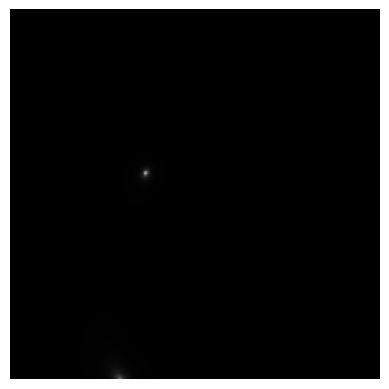

In [23]:
imsim = rg.Resim(gtw.iloc[0],param=param,verbose=0)
im = imsim.getImage()
imshow( im )

We can make the same simulation from the reconstructed amplitudes and compare.

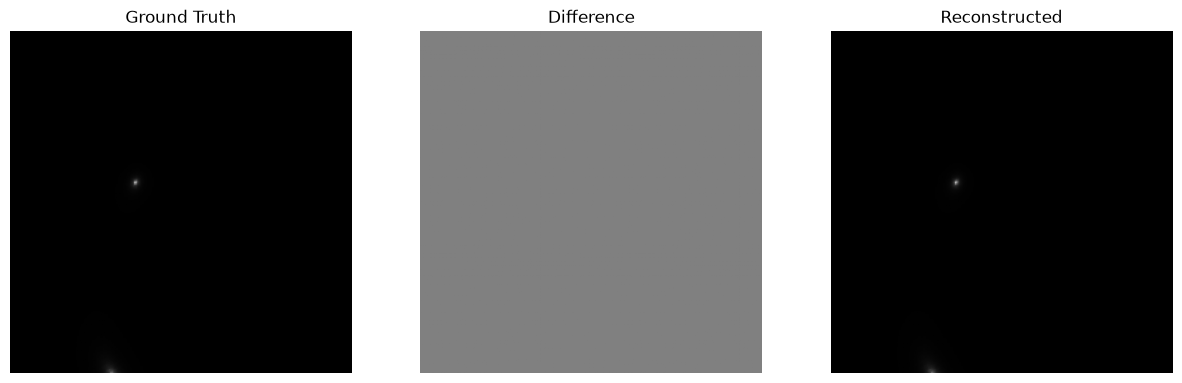

In [24]:
dfw = df.loc[ worst ]
imsim2 = rg.Resim(dfw.iloc[0],param=param,verbose=0)
im2 = imsim2.getImage()
csimg.imageCompare( im, im2, "Ground Truth", "Reconstructed" )

This looks like perfect match.

We can do the same for all the top and bottom three.

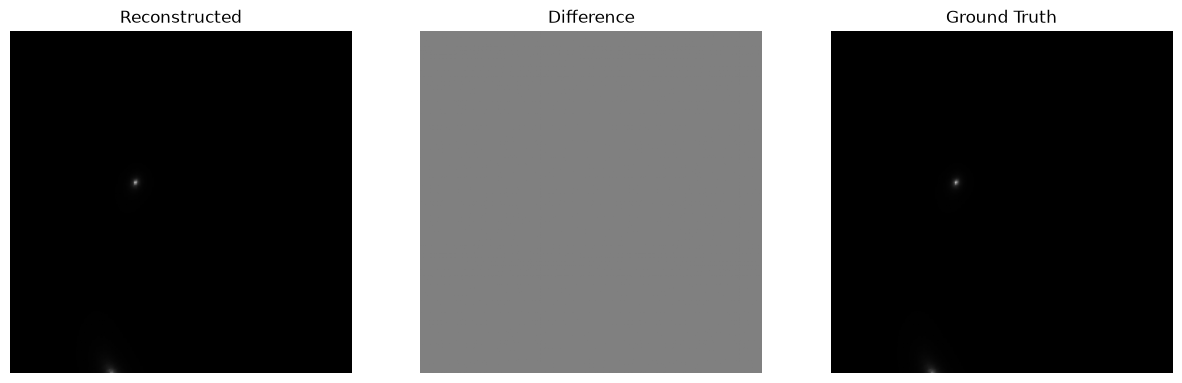

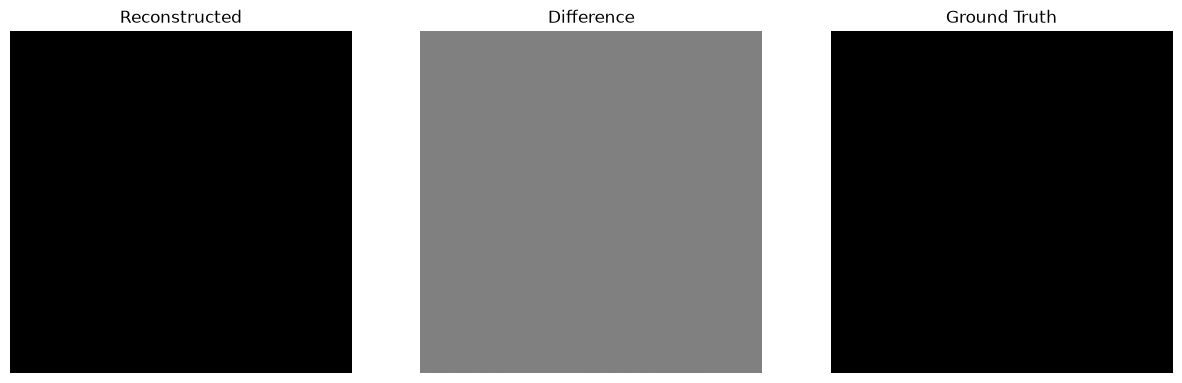

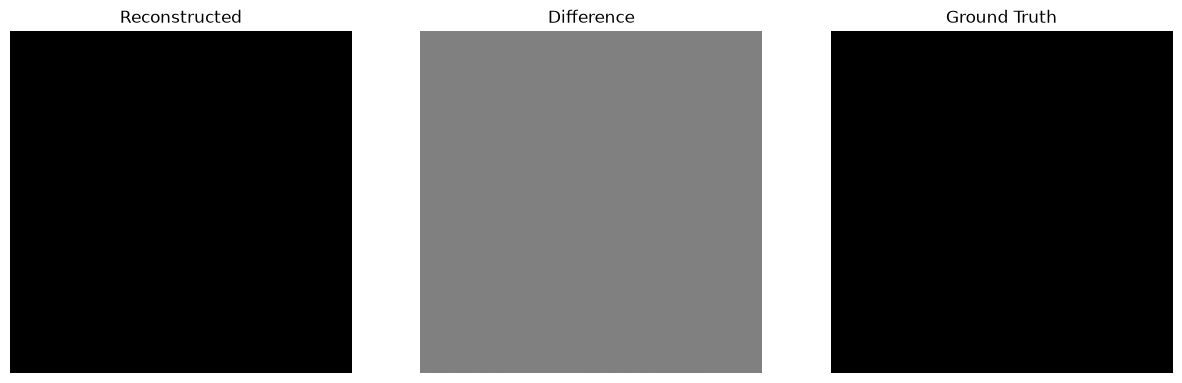

In [25]:
for fn in worst:
    dfsim = rg.Resim(df.loc[fn],param=param,verbose=0)
    dfim = dfsim.getImage()
    gtsim = rg.Resim(gt.loc[fn],param=param,verbose=0)
    gtim = gtsim.getImage()
    csimg.imageCompare( dfim, gtim, "Reconstructed", "Ground Truth" )

No visible discrepancy.  We can continue with the best images, obviously expecting perfect match again.

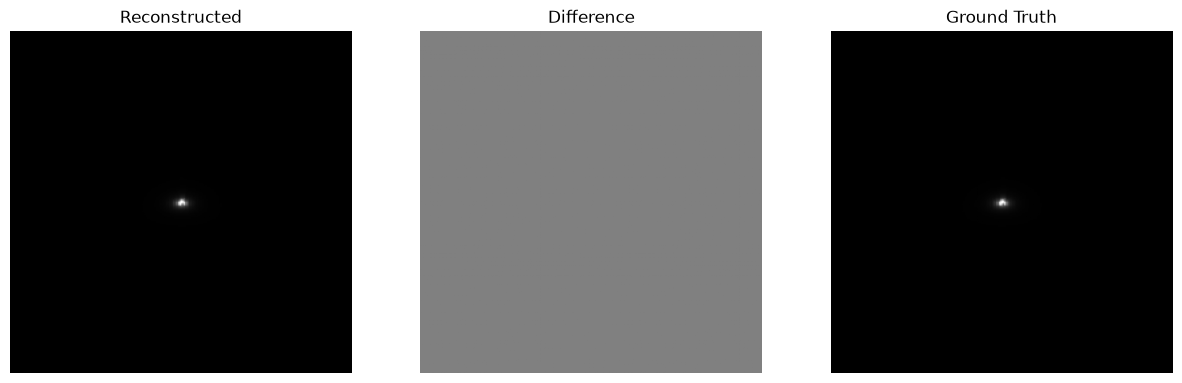

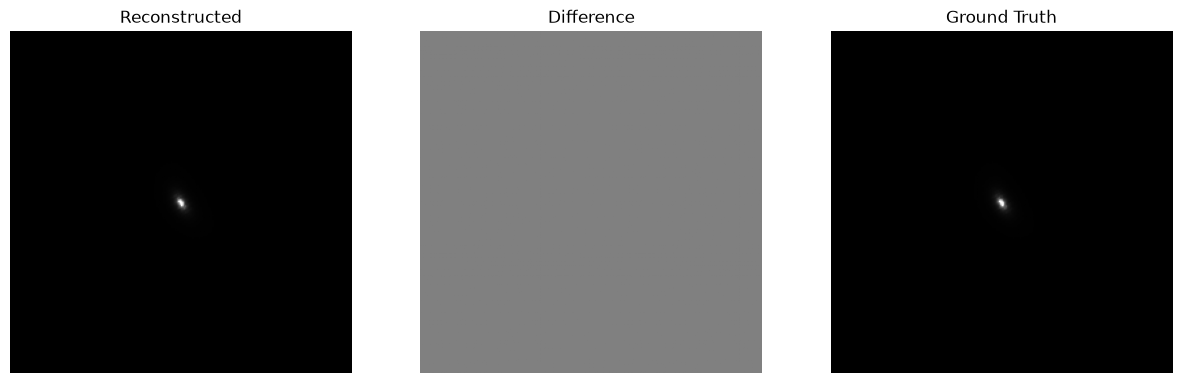

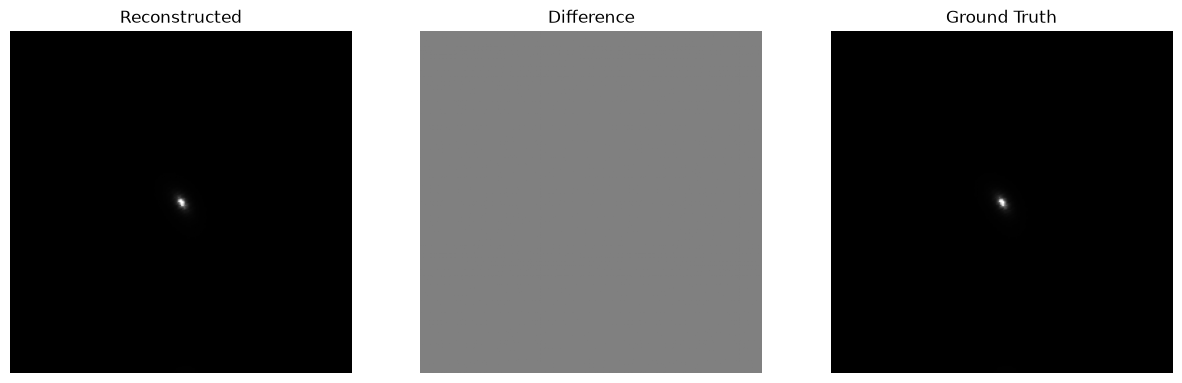

In [26]:
for fn in best:
    dfsim = rg.Resim(df.loc[fn],param=param,verbose=0)
    dfim = dfsim.getImage()
    gtsim = rg.Resim(gt.loc[fn],param=param,verbose=0)
    gtim = gtsim.getImage()
    csimg.imageCompare( dfim, gtim, "Reconstructed", "Ground Truth" )

## Numerical errors

In [27]:
gtw = gt.loc[ worst ]
dfw = df.loc[ worst ]
display( gtw - dfw )

,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-013124.png,-2.388884e-07,3.020550e-07,-2.297133e-05,-8.385182e-06,-1.851225e-06,2.391031e-08,5.813318e-09,8.932280e-09,8.037170e-11,1.254909e-10,...,-1.626757e-13,-6.336245e-13,-1.192602e-12,2.072681e-13,-5.270811e-14,1.888414e-14,-7.790773e-14,-8.438341e-14,-1.792544e-14,2.308819e-14
image-014478.png,8.759813e-08,-2.197769e-05,-5.766802e-07,9.703906e-06,-2.625755e-07,2.489420e-09,7.526372e-09,2.004169e-09,-1.469925e-10,3.878800e-12,...,6.297849e-14,2.018915e-13,1.139743e-13,3.242925e-14,-9.916425e-15,-5.300196e-15,5.484849e-14,2.875743e-14,3.045563e-14,6.644559e-15
image-015910.png,3.411734e-07,5.051152e-08,1.733333e-05,1.226040e-07,-1.656172e-05,1.327012e-08,6.910047e-09,-2.812335e-10,-6.939604e-13,3.931740e-11,...,8.329448e-14,-4.769949e-14,-2.062640e-13,-1.358089e-13,2.639096e-14,-2.008907e-15,-6.009995e-14,-6.792502e-14,-3.086560e-14,1.709503e-14


In [28]:
display( (gtw - dfw)/gtw )

,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-013124.png,-5.063983e-08,-5.842945e-09,1.774195e-07,-9.532743e-08,-2.517085e-08,-8.881043e-08,4.725243e-08,4.008016e-08,-3.562786e-08,-6.185479e-08,...,6.206441e-08,1.865235e-08,4.202278e-08,6.311002e-09,1.054521e-07,-2.910526e-08,-2.490328e-07,1.848102e-07,1.936581e-08,9.993751e-08
image-014478.png,5.742840e-08,-8.116553e-08,1.254257e-08,-9.364843e-08,-3.688034e-08,-1.145850e-08,3.526282e-08,1.086382e-07,-1.062193e-07,-6.969715e-09,...,-1.182820e-08,3.007321e-08,9.231831e-09,-2.858089e-08,-6.299088e-08,2.137290e-07,3.961331e-06,-2.898837e-07,-1.950214e-07,2.602238e-07
image-015910.png,6.867854e-08,-3.401150e-09,-5.343419e-08,-9.767586e-09,-1.095504e-07,-6.153245e-08,-3.245198e-08,3.381564e-08,-1.267491e-08,-3.377100e-08,...,1.115048e-08,-3.150705e-07,-2.027531e-08,1.584770e-06,1.661419e-05,3.603625e-08,-1.506305e-05,-8.561622e-07,-3.326401e-06,1.312633e-07


There are some numbers that stick out as particularly large, but that's still on the order of $10^{-5}$ at worst.

In [31]:
gtb = gt.loc[ best ]
dfb = df.loc[ best ]
display( gtb - dfb )

,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-012644.png,3.580809e-08,-2.434903e-08,1.872933e-08,-2.410609e-08,1.166764e-08,1.904450e-08,1.347183e-08,-3.907749e-10,-7.388700e-12,1.030721e-10,...,-1.457416e-12,-1.546820e-14,-6.889352e-13,-8.216299e-14,1.241805e-14,1.160695e-15,1.359429e-14,-2.023432e-13,5.827606e-14,-2.139250e-14
image-012491.png,-6.616709e-08,-2.400291e-08,-4.480049e-08,-2.313054e-08,3.695039e-08,1.547427e-08,1.200482e-09,-2.658573e-09,1.985065e-10,1.395069e-10,...,7.172447e-13,6.188916e-13,2.093662e-12,-1.033587e-12,-4.387769e-14,-1.620042e-15,-5.555808e-14,-5.388269e-14,-8.762627e-14,1.070639e-14
image-012487.png,1.852136e-08,1.340575e-08,7.052360e-08,-4.835183e-08,5.238902e-08,1.403179e-08,2.997693e-09,5.900479e-09,7.755010e-11,-4.410350e-11,...,-1.880402e-14,-1.564241e-13,3.773769e-12,9.771156e-14,-2.343401e-14,5.536252e-14,-1.438079e-13,-6.101712e-14,-4.348595e-15,3.052032e-14


In [32]:
display( (gtb - dfb)/gtb )

,sigma,xiX,xiY,alpha[0][1],beta[0][1],alpha[1][0],alpha[1][2],beta[1][2],alpha[2][1],beta[2][1],...,alpha[3][2],beta[3][2],alpha[3][4],beta[3][4],alpha[4][1],beta[4][1],alpha[4][3],beta[4][3],alpha[4][5],beta[4][5]
filename,,,,,,,,,,,,,,,,,,,,,
image-012644.png,1.514303e-08,2.952915e-08,3.134850e-08,3.907756e-08,-2.439654e-10,-9.374051e-08,-6.668522e-08,9.121556e-08,-4.274152e-08,4.309816e-08,...,-3.431369e-08,4.250427e-09,-1.461057e-08,-4.826357e-07,-2.091632e-07,4.974863e-09,-9.912533e-08,1.789297e-07,-2.163745e-05,1.623489e-08
image-012491.png,-2.748837e-08,2.059648e-08,-6.373142e-08,-4.267158e-10,1.270364e-09,-7.238759e-08,1.175214e-08,-1.417259e-08,-8.844087e-08,-1.073300e-07,...,-4.056787e-08,-2.042597e-08,-7.799234e-08,-2.407107e-08,6.603846e-08,1.071272e-08,-6.387059e-07,7.414171e-08,7.172696e-08,1.709651e-08
image-012487.png,1.053597e-08,-1.843868e-08,6.846532e-08,1.212568e-09,-1.205455e-09,-6.594902e-08,4.002294e-08,3.187916e-08,5.244616e-08,-1.772790e-08,...,-1.266885e-09,6.307863e-09,-1.163129e-07,5.546405e-09,-4.629875e-08,4.022552e-08,1.022273e-06,9.345510e-07,-6.394152e-09,5.043772e-07


## Simulations from Lens Parameters

We can also load the original lens parameters, from which 
the ground truth was computed.

In [33]:
orig = pd.read_csv( "dataset.csv", index_col="filename" )
display( orig.head() )

,index,model,cluster,source,R,phi,sigma,sigma2,theta,n_sersic,luminosity,x,y
filename,,,,,,,,,,,,,
image-000001.png,1,Raytrace,SIE/4.185227969633666/-5.495486496994903/60.16...,SersicSphere,9.7891,204.4501,2.2251,30.7254,82.4354,1.4926,19.9553,-8.9112,-4.0517
image-000002.png,2,Raytrace,SIE/-6.526612974030754/4.955576445652201/14.24...,SersicSphere,32.4897,68.0571,4.7329,25.1133,27.3646,4.5678,14.5370,12.1408,30.1360
image-000003.png,3,Raytrace,SIE/-3.6522133090691957/-12.902592284040816/44...,SersicSphere,29.3320,160.5163,1.7543,1.3398,124.4357,1.0166,19.6730,-27.6524,9.7834
image-000004.png,4,Raytrace,SIE/8.91680515181728/31.53988273167426/42.9541...,SersicSphere,58.8160,6.1906,1.0707,34.4136,165.1151,4.6807,15.5296,58.4730,6.3425
image-000005.png,5,Raytrace,SIE/-3.4786844195740776/16.230831507844613/57....,SersicSphere,26.3089,145.2252,2.7028,14.0243,156.4511,1.5156,16.0664,-21.6102,15.0054


This dataset is different from the others, giving physical parameters
of the lens instead of roulette amplitudes in a point of observation.
Thus, we need a different simulator.  On a positive note, we can use
raytrace simulation, which is accurate.

The `SimImage` simulator is parameterised in a slightly different
way.  We need to add the row data from the dataset to the 
`Parameters` object instead of passing it as a separate argument.
To avoid interference, we make a copy of `params`.

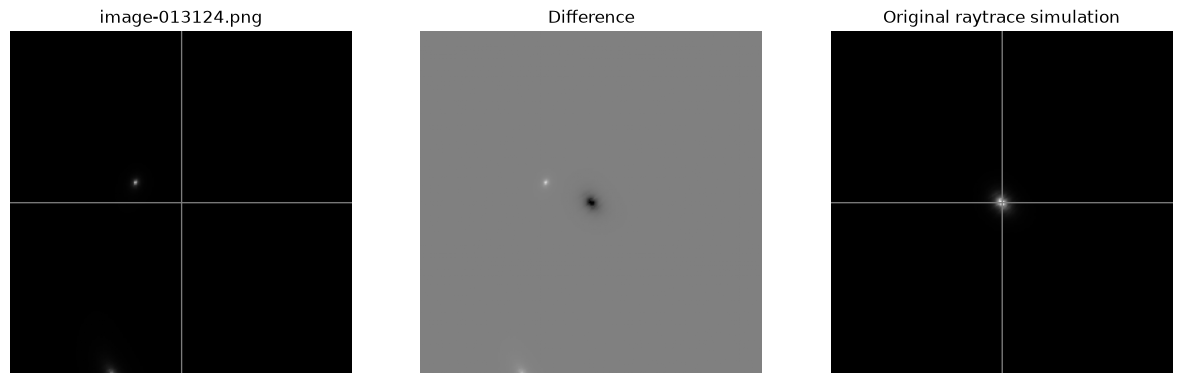

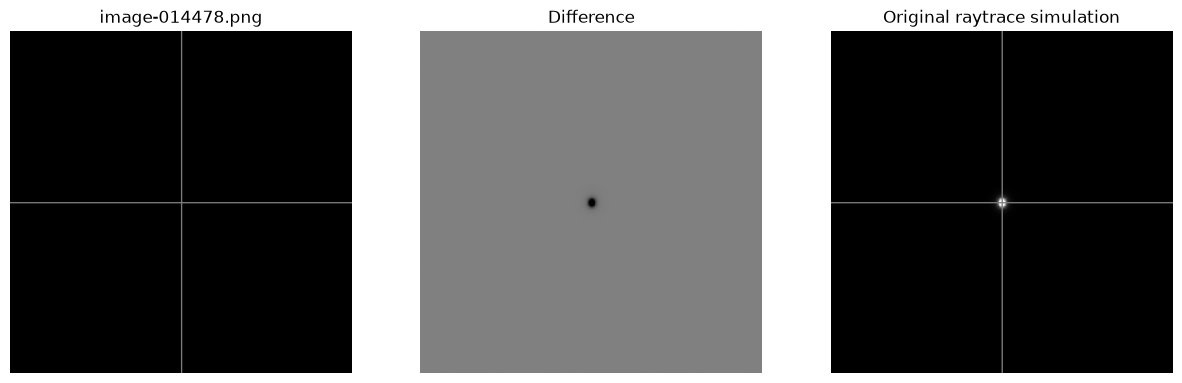

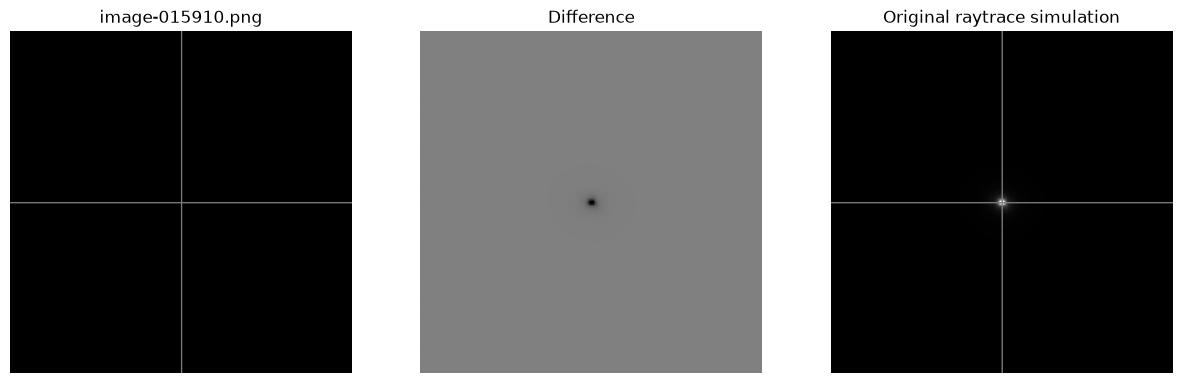

In [34]:
cfg["simulator"]["config"] = "raysie"
cfg["simulator"]["centred"] = True
p2 = cs.Parameters( cfg )
for fn in worst:
    dfsim = rg.Resim(df.loc[fn],param=param,verbose=0)
    dfim = dfsim.getImage()
    p2.setRow( orig.loc[fn] )
    gtsim = dg.SimImage(param=p2,verbose=0)
    gtim = gtsim.getImage()
    csimg.imageCompare( dfim, gtim, fn, "Original raytrace simulation", axiscross=True )

This is not good, and with the small visible images, it is difficult to tell what the problem is.

Finally, we can also plot the best objects with raytrace simulation.

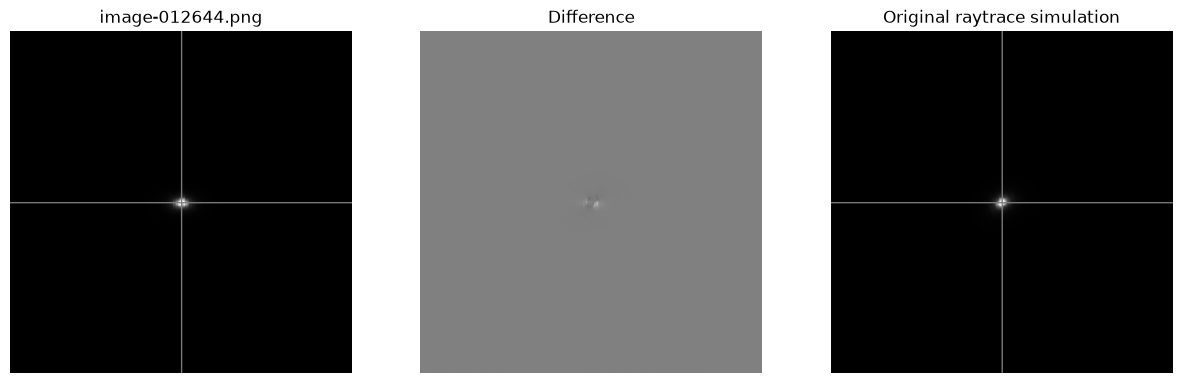

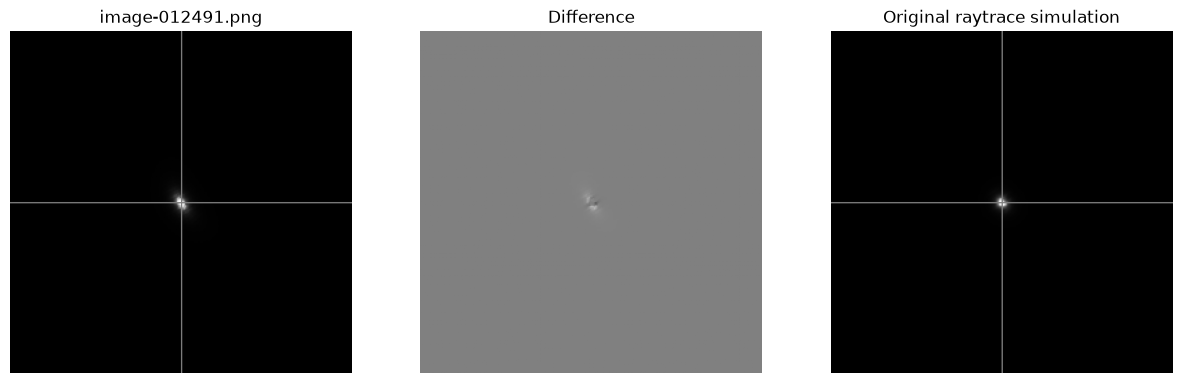

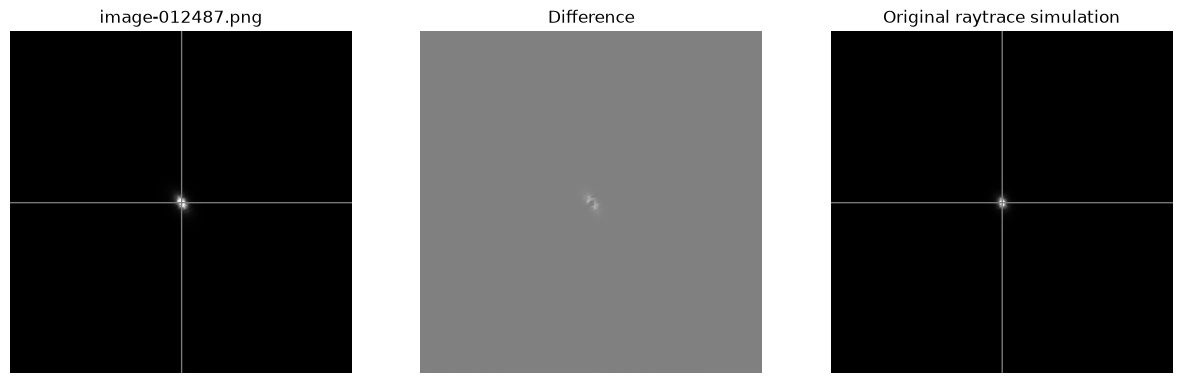

In [36]:
for fn in best:
    dfsim = rg.Resim(df.loc[fn],param=param,verbose=0)
    dfim = dfsim.getImage()
    p2.setRow( orig.loc[fn] )
    gtsim = dg.SimImage(param=p2,verbose=0)
    gtim = gtsim.getImage()
    csimg.imageCompare( dfim, gtim, fn, "Original raytrace simulation", axiscross=True )

## Conclusion

We see that this machine learning model make accurate prediction as far as optical perception goes.
Other datasets may prove harder, but this dataset gives no room for further tuning.